# Bengaluru House Price Prediction

**My goal:** practice regression by estimating a listed house price from details such as area, location and number of bedrooms. I will compare a simple baseline with a couple of ML models and see how far their predictions are from the listed prices.

This is a learning project, not a real property valuation.

Estimate a listing's price from property features in the Bengaluru house-price dataset.

**Dataset:** Kaggle *Bengaluru House Price Data* (`Bengaluru_House_Data.csv`).
Download from https://www.kaggle.com/datasets/amitabhajoy/bengaluru-house-price-data and place the CSV beside this notebook.

The target is `price` (dataset units are typically lakh rupees). This is a regression exercise, not a formal property valuation.


In [1]:
# Imports and setup
# I will use these libraries for tables, plots and the ML models below.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("Bengaluru_House_Data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError('Bengaluru_House_Data.csv')

df = pd.read_csv(DATA_PATH)
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include="all").T)
print("Missing values:\n", df.isna().sum().sort_values(ascending=False).head(15))
print("Duplicate rows:", df.duplicated().sum())


Shape: (13320, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_type,13320,4,Super built-up Area,8790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability,13320,81,Ready To Move,10581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,13319,1305,Whitefield,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,13304,31,2 BHK,5199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
society,7818,2688,GrrvaGr,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sqft,13320,2117,1200,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath,13247.0,NaN,NaN,NaN,2.69261,1.341458,1.0,2.0,2.0,3.0,40.0
balcony,12711.0,NaN,NaN,NaN,1.584376,0.817263,0.0,1.0,2.0,2.0,3.0
price,13320.0,NaN,NaN,NaN,112.565627,148.971674,8.0,50.0,72.0,120.0,3600.0


Missing values:
 society         5502
balcony          609
bath              73
size              16
location           1
area_type          0
availability       0
total_sqft         0
price              0
dtype: int64
Duplicate rows: 529


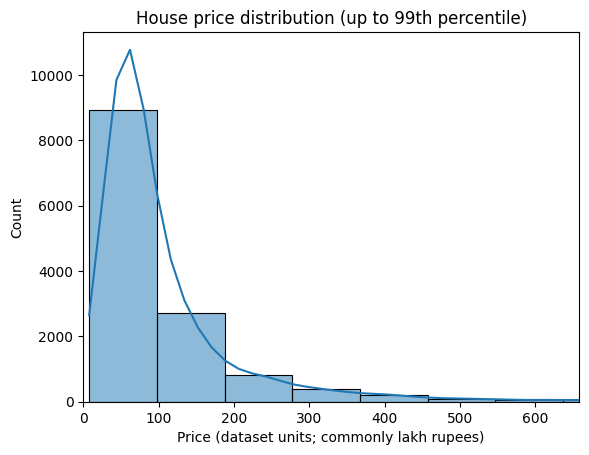

In [3]:
# Initial target inspection. Dataset prices are commonly expressed in lakh rupees.
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"]).copy()
sns.histplot(df["price"], bins=40, kde=True)
plt.xlim(0, df["price"].quantile(0.99))
plt.title("House price distribution (up to 99th percentile)")
plt.xlabel("Price (dataset units; commonly lakh rupees)")
plt.show()


## Cleaning up a few columns
Some columns are not ready for a model as they are. For example, `size` can contain text like `2 BHK`, so I extract the number of bedrooms. `total_sqft` sometimes contains a range, so I use the average of the numbers I find. If I cannot turn a value into a number, I leave it missing and let the preprocessing step fill it in. I drop `society` because it can have lots of missing values.


In [4]:
import re

def sqft_to_number(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().replace(",", "")
    # Handle ranges such as " present  ... " by extracting numeric values.
    nums = re.findall(r"\d+(?:\.\d+)?", s)
    if not nums:
        return np.nan
    vals = [float(n) for n in nums]
    return sum(vals) / len(vals) if len(vals) > 1 else vals[0]

data = df.copy()
data["total_sqft"] = data["total_sqft"].apply(sqft_to_number)
data["bedrooms"] = data["size"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand=False)
data["bedrooms"] = pd.to_numeric(data["bedrooms"], errors="coerce")
data = data.drop(columns=[c for c in ["size", "society", "availability"] if c in data.columns])
data = data.replace([np.inf, -np.inf], np.nan)
data.head()


,area_type,location,total_sqft,bath,balcony,price,bedrooms
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [5]:
# Filter obviously unusable rows; retain valid numeric target rows.
data = data.dropna(subset=["price"])
X = data.drop(columns=["price"])
y = data["price"]

# Keep a simple, reproducible random holdout.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['total_sqft', 'bath', 'balcony', 'bedrooms']
Categorical: ['area_type', 'location']


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5))
    ]), categorical_features)
])

models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, min_samples_leaf=2)
}
results = []
fitted = {}
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted[name] = pipe
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })
results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,Model,MAE,RMSE,R2
2,Random Forest,32.147308,88.226035,0.634399
1,Linear Regression,39.374310,93.279879,0.591314
0,Median baseline,62.633605,151.049058,-0.071641


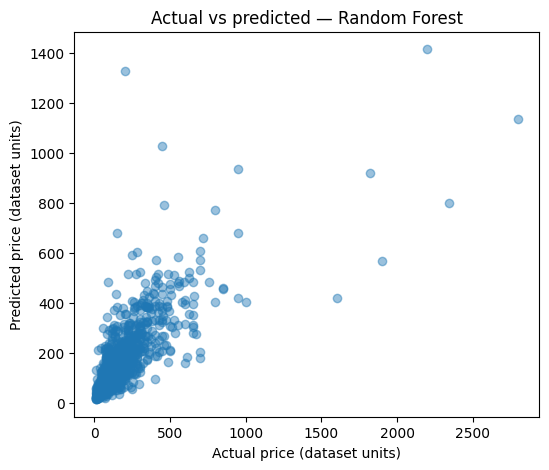

Selected model: Random Forest
MAE: 32.14730793108556
RMSE: 88.22603515261626
R²: 0.6343994107189297


In [7]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted[best_name]
pred = best_model.predict(X_test)

plt.figure(figsize=(6,5))
plt.scatter(y_test, pred, alpha=0.45)
plt.xlabel("Actual price (dataset units)")
plt.ylabel("Predicted price (dataset units)")
plt.title(f"Actual vs predicted — {best_name}")
plt.show()

print("Selected model:", best_name)
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))


In [8]:
# Inspect a sample prediction.
example = X_test.iloc[[0]]
display(example)
print("Predicted price (dataset units):", round(float(best_model.predict(example)[0]), 2))
print("Actual price:", y_test.iloc[0])


,area_type,location,total_sqft,bath,balcony,bedrooms
8077,Built-up Area,Banjara Layout,1050.0,2.0,1.0,2.0


Predicted price (dataset units): 65.01
Actual price: 64.8


C:\Users\NAITEEK JAIN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\NAITEEK JAIN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\NAITEEK JAIN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\NAITEEK JAIN\

In [9]:
import joblib
joblib.dump(best_model, "bengaluru_house_price_pipeline.joblib")
print("Saved: bengaluru_house_price_pipeline.joblib")


Saved: bengaluru_house_price_pipeline.joblib


## Notes and possible improvements
- The dataset has listing information, so prices and area measurements may be inconsistent or outdated.
- I used a random train/test split. Results may change with a different split and may not represent future listings.
- These outputs are practice estimates, not official property valuations.
- If I continue this project, I can inspect unusual area/price values, try cross-validation, tune the model and build a simple Streamlit form.
